# Regression Model Development Guide (Simplified)

A step-by-step template for building and comparing regression models:
- **Linear Regression** (Baseline)
- **Random Forest**
- **LightGBM**
- **XGBoost**
- **CatBoost**

---

## Step 1: Identify the Target Variable (y)

Define the variable you want to predict (the dependent variable).

In [567]:
# ========== MODIFY THIS ==========
TARGET_COLUMN = 'resale_price'  # Target column for HDB resale price prediction
# =================================

---

## Step 2: Import Packages and Load Dataset

In [568]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

# Import regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

# Configure plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.style.use('fivethirtyeight')

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("All packages imported successfully!")

All packages imported successfully!


In [569]:
# ========== MODIFY THIS ==========
# Load your dataset
DATA_PATH = 'Consolidated Flat Transactions.csv'
# =================================

df = pd.read_csv(DATA_PATH)

# Preview the data
print(f"Dataset loaded with shape: {df.shape}")
df.head()

Dataset loaded with shape: (270619, 76)


,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,2012-03,ANG MO KIO,5 ROOM,101,ANG MO KIO AVE 3,06 TO 10,117.0,Standard,1978,515000.0,...,61,0,1.369092,103.839041,474.789674,Ang Mo Kio Secondary School,224,0,1.367359,103.842600
1,2012-03,ANG MO KIO,3 ROOM,103,ANG MO KIO AVE 3,06 TO 10,73.0,New Generation,1978,368000.0,...,61,0,1.369092,103.839041,522.935557,Mayflower Secondary School,219,0,1.368337,103.835439
2,2012-03,ANG MO KIO,4 ROOM,105,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,430000.0,...,61,0,1.369092,103.839041,398.421190,CHIJ Saint Nicholas Girls' School,256,1,1.373730,103.834309
3,2012-03,ANG MO KIO,4 ROOM,108,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,427000.0,...,61,0,1.369092,103.839041,424.046635,Mayflower Secondary School,219,0,1.368337,103.835439
4,2012-03,ANG MO KIO,3 ROOM,110,ANG MO KIO AVE 4,01 TO 05,67.0,New Generation,1978,323000.0,...,61,0,1.369092,103.839041,322.732547,Mayflower Secondary School,219,0,1.368337,103.835439


---

## Step 3: Explore the Dataset Structure

Check the number of features, data types, and basic statistics.

In [570]:
# Check dimensions (rows, columns)
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print("\n" + "="*50)

# View column names and data types
print("\nColumn Info:")
print(df.info())

Dataset shape: (270619, 76)
Number of features: 76


Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270619 entries, 0 to 270618
Data columns (total 76 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Tranc_YearMonth            270619 non-null  object 
 1   town                       270619 non-null  object 
 2   flat_type                  270619 non-null  object 
 3   block                      270619 non-null  object 
 4   street_name                270619 non-null  object 
 5   storey_range               270619 non-null  object 
 6   floor_area_sqm             270619 non-null  float64
 7   flat_model                 270619 non-null  object 
 8   lease_commence_date        270619 non-null  int64  
 9   resale_price               270619 non-null  float64
 10  Tranc_Year                 270619 non-null  int64  
 11  Tranc_Month                270619 non-null  int64  
 12  mid_storey          

In [571]:
# View basic statistics for numeric columns
df.describe()

,floor_area_sqm,lease_commence_date,resale_price,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,floor_area_sqft,...,pri_sch_nearest_distance,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
count,270619.000000,270619.000000,2.706190e+05,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,...,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000
mean,96.688538,1994.860209,5.077318e+05,2019.382867,6.569993,8.540509,7.520218,9.560800,8.540509,1040.751170,...,410.333804,49.501099,0.110421,1.367462,103.839956,524.446040,119.498162,0.036088,1.367066,103.840203
std,24.158391,13.743470,1.758274e+05,3.938842,3.322633,5.753127,5.757832,5.751876,5.753127,260.039993,...,246.979262,20.722907,0.313414,0.042797,0.071881,315.536641,97.268801,0.186509,0.042629,0.071779
min,31.000000,1966.000000,1.500000e+05,2012.000000,1.000000,2.000000,1.000000,3.000000,2.000000,333.680900,...,42.554863,0.000000,0.000000,1.274962,103.687589,38.913475,5.000000,0.000000,1.276029,103.687207
25%,76.000000,1984.000000,3.800000e+05,2016.000000,4.000000,5.000000,4.000000,6.000000,5.000000,818.056400,...,232.375000,32.000000,0.000000,1.337408,103.776108,297.943031,19.000000,0.000000,1.338179,103.777148
50%,93.000000,1995.000000,4.730000e+05,2020.000000,7.000000,8.000000,7.000000,9.000000,8.000000,1001.052000,...,361.106748,48.000000,0.000000,1.365518,103.844934,459.407453,188.000000,0.000000,1.367107,103.844934
75%,112.000000,2004.000000,6.038880e+05,2023.000000,9.000000,11.000000,10.000000,12.000000,11.000000,1205.556800,...,524.571779,64.000000,0.000000,1.394958,103.898773,669.551509,211.000000,0.000000,1.396218,103.899872
max,366.700000,2022.000000,1.658888e+06,2025.000000,12.000000,50.000000,49.000000,51.000000,50.000000,3947.122130,...,3306.003143,138.000000,1.000000,1.456667,103.962919,3638.977233,260.000000,1.000000,1.453280,103.961105


In [572]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing Values:")
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values:
                       Missing Count  Missing %
Mall_Nearest_Distance           5210       1.93
Mall_Within_500m              168137      62.13
Mall_Within_1km                49132      18.16
Mall_Within_2km                 7036       2.60
Hawker_Within_500m            177013      65.41
Hawker_Within_1km             109046      40.30
Hawker_Within_2km              52516      19.41


---

## Step 3.5: Feature Engineering (Optional)

Create new features by combining or transforming existing columns. This can help capture relationships that improve model performance.

**Common feature engineering techniques:**
- **Ratio features**: e.g., `floor_ratio = mid_storey / max_floor_lvl` (relative floor position)
- **Interaction features**: e.g., `area_x_storey = floor_area_sqm * mid_storey`
- **Binning**: e.g., categorizing `hdb_age` into groups
- **Log transformations**: e.g., `log_price = log(resale_price)`

> **Warning:** Avoid features derived from the target variable (e.g., `price_per_sqm = resale_price / floor_area_sqm`) as this creates **data leakage**. See `Price_Per_Sqm_Analysis.ipynb` for details.

### Feature Typing Checklist

Use this quick check before adding an engineered feature to feature lists.

1. Is the final feature a continuous value or ordered number?
- Put it in numeric or engineered features.

2. Is it a binary flag coded as 0/1?
- Usually keep it in engineered features (treated as numeric).
- Example: mature_estate.

3. Is it a label or category name (text), or a number that is just a code with no numeric meaning?
- Put it in categorical features and encode it.

4. If the value increases by 1, does that have meaningful numeric interpretation?
- Yes: numeric or engineered.
- No: categorical.

5. Check null behavior before Step 6 dropna.
- Confirm whether the new feature introduces additional missing values.
- If needed, add explicit imputation in Step 3.5.

In [573]:
# ========== FEATURE ENGINEERING SECTION ==========
# Add new engineered features below. Each feature is created from existing columns.

# Example 1: Relative floor position (0-1 scale, where 1 = top floor)
# Captures floor premium without being perfectly correlated with mid_storey or max_floor_lvl
#df['floor_ratio'] = df['mid_storey'] / df['max_floor_lvl']

df['remaining_lease'] = 99 - df['hdb_age']
# Note: highly correlated with hdb_age

# Example 2: Distance from CBD (in km)
# Captures centrality premium using latitude and longitude
def haversine(lat1, lon1, lat2, lon2):
    radius_km = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = (
        np.sin(delta_phi / 2) ** 2
        + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2) ** 2
    )
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return radius_km * c

cbd_lat, cbd_lon = 1.2897, 103.8501
df['cbd_distance'] = haversine(df['Latitude'], df['Longitude'], cbd_lat, cbd_lon)

# Example 3: Mature estate flag (1 = mature estate, 0 = non-mature estate)
mature_estates = [
    'ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT MERAH', 'BUKIT TIMAH',
    'CENTRAL AREA', 'CLEMENTI', 'GEYLANG', 'KALLANG/WHAMPOA',
    'MARINE PARADE', 'PASIR RIS', 'QUEENSTOWN', 'SERANGOON',
    'TAMPINES', 'TOA PAYOH'
 ]
df['mature_estate'] = df['town'].str.upper().isin(mature_estates).astype(int)

# Example 4: Inverse rental units (explicit fillna approach)
rental_cols = ['1room_rental', '2room_rental', '3room_rental', 'other_room_rental']
df['total_rental_units'] = df[rental_cols].fillna(0).sum(axis=1)
df['inverse_rental_units'] = 1 / (1 + df['total_rental_units'])

# Example 6: DBSS flag (1 = DBSS flat, 0 = non-DBSS)
# Note: high multicollinearity expected with flat_model (which is in CATEGORICAL_FEATURES).
# Kept as an explicit flag since DBSS flats command a large price premium (~$773k median vs ~$473k overall).
df['is_dbss'] = df['flat_model'].fillna('').str.upper().str.contains('DBSS').astype(int)

# Example 7: Mixed-use score (0 = residential only, 1 = one mixed-use feature, 2 = both)
# Captures whether the block has commercial units or a precinct pavilion.
df['mixed_use_score'] = (
    (df['commercial'].astype(str).str.upper() == 'Y').astype(int)
    + (df['precinct_pavilion'].astype(str).str.upper() == 'Y').astype(int)
)

# Example 8: Cutoff-aligned z-score (secondary school quality, regime-adjusted)
# cutoff_point changed direction in 2021: pre-2021 higher=better, post-2021 lower=better.
# Z-scored within each regime, then post-2021 sign is flipped so higher always = better school.
def _zscore(s):
    return (s - s.mean()) / s.std(ddof=0)

pre_mask  = df['Tranc_Year'] < 2021
post_mask = ~pre_mask
df['cutoff_aligned_z'] = np.nan
df.loc[pre_mask,  'cutoff_aligned_z'] =  _zscore(df.loc[pre_mask,  'cutoff_point'])
df.loc[post_mask, 'cutoff_aligned_z'] = -_zscore(df.loc[post_mask, 'cutoff_point'])

# Example 5: Uncomment and modify these or add your own
# df['area_x_storey'] = df['floor_area_sqm'] * df['mid_storey']
# df['distance_score'] = df['mrt_nearest_distance'] + df['Mall_Nearest_Distance']
# df['remaining_lease'] = 99 - df['hdb_age']  # Note: highly correlated with hdb_age

# ========== ADD YOUR CUSTOM FEATURES BELOW ==========
# 
# Template: df['new_feature_name'] = <formula using existing columns>
# 
# Example ideas:
# - df['total_distance'] = df['mrt_nearest_distance'] + df['Mall_Nearest_Distance'] + df['Hawker_Nearest_Distance']
# - df['is_high_floor'] = (df['mid_storey'] > 10).astype(int)
# - df['age_squared'] = df['hdb_age'] ** 2
# 
# Optional liveability feature is kept in separate Step 3.5 cells below so it can be removed cleanly later.
# 
# ⚠️ AVOID: Features derived from target (e.g., price_per_sqm = resale_price / floor_area_sqm)
#    This creates DATA LEAKAGE. See Price_Per_Sqm_Analysis.ipynb for details.
# 
# =================================================

# Display the newly created columns
new_columns = ['cbd_distance', 'mature_estate', 'inverse_rental_units', 'is_dbss', 'mixed_use_score', 'cutoff_aligned_z']
print("\nEngineered Features Created:")
for col in new_columns:
    if col in df.columns:
        print(f"  - {col}: min={df[col].min():.2f}, max={df[col].max():.2f}, mean={df[col].mean():.2f}")

print(f"\nDataset now has {df.shape[1]} columns")
df.head()



Engineered Features Created:
  - cbd_distance: min=0.69, max=19.58, mean=11.97
  - mature_estate: min=0.00, max=1.00, mean=0.43
  - inverse_rental_units: min=0.00, max=1.00, mean=0.98
  - is_dbss: min=0.00, max=1.00, mean=0.01
  - mixed_use_score: min=0.00, max=1.00, mean=0.18
  - cutoff_aligned_z: min=-1.10, max=3.03, mean=0.00

Dataset now has 84 columns


,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,sec_sch_latitude,sec_sch_longitude,remaining_lease,cbd_distance,mature_estate,total_rental_units,inverse_rental_units,is_dbss,mixed_use_score,cutoff_aligned_z
0,2012-03,ANG MO KIO,5 ROOM,101,ANG MO KIO AVE 3,06 TO 10,117.0,Standard,1978,515000.0,...,1.367359,103.842600,52,9.035674,1,0,1.0,0,0,0.695045
1,2012-03,ANG MO KIO,3 ROOM,103,ANG MO KIO AVE 3,06 TO 10,73.0,New Generation,1978,368000.0,...,1.368337,103.835439,52,9.121278,1,0,1.0,0,0,0.445045
2,2012-03,ANG MO KIO,4 ROOM,105,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,430000.0,...,1.373730,103.834309,52,9.290662,1,0,1.0,0,0,2.295045
3,2012-03,ANG MO KIO,4 ROOM,108,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,427000.0,...,1.368337,103.835439,52,9.132691,1,0,1.0,0,1,0.445045
4,2012-03,ANG MO KIO,3 ROOM,110,ANG MO KIO AVE 4,01 TO 05,67.0,New Generation,1978,323000.0,...,1.368337,103.835439,52,9.089999,1,0,1.0,0,0,0.445045


In [574]:
# Null diagnostics for rental columns
rental_cols = ['1room_rental', '2room_rental', '3room_rental', 'other_room_rental']

null_count = df[rental_cols].isna().sum()
null_pct = (df[rental_cols].isna().mean() * 100).round(2)
null_summary = pd.DataFrame({
    'null_count': null_count,
    'null_pct': null_pct
}).sort_values('null_pct', ascending=False)

row_any_null = df[rental_cols].isna().any(axis=1)
row_all_null = df[rental_cols].isna().all(axis=1)

print('Rental column null summary (% of rows):')
print(null_summary.to_string())
print(f"\nRows with any rental null: {row_any_null.sum()} ({row_any_null.mean() * 100:.2f}%)")
print(f"Rows with all rental columns null: {row_all_null.sum()} ({row_all_null.mean() * 100:.2f}%)")

Rental column null summary (% of rows):
                   null_count  null_pct
1room_rental                0       0.0
2room_rental                0       0.0
3room_rental                0       0.0
other_room_rental           0       0.0

Rows with any rental null: 0 (0.00%)
Rows with all rental columns null: 0 (0.00%)


### Step 3.5A: Optional Liveability Index

This subsection ports the EDA-based liveability feature into the modelling notebook.

It is intentionally isolated so you can remove these cells later if the feature causes too many rows to be dropped in Step 6.

In [575]:
# Optional feature: liveability_index (5-pillar, includes secondary school)
# Not currently in ENGINEERED_FEATURES.
# To switch to this variant: add 'liveability_index' to ENGINEERED_FEATURES in Step 4
# and remove 'liveability_nocut_4pillar'.


# --- Secondary school tier encoding ---
def sec_school_tier(row):
    year = row['Tranc_Year']
    cutoff = row['cutoff_point']

    if pd.isna(cutoff):
        return np.nan

    if year < 2021:
        return 'Tier 1' if cutoff >= 240 else 'Tier 2'

    return 'Tier 1' if cutoff <= 11 else 'Tier 2'

df['sec_school_tier'] = df.apply(sec_school_tier, axis=1)
tier_map = {'Tier 1': 1, 'Tier 2': 2}
df['school_tier_encoded'] = df['sec_school_tier'].map(tier_map)

# --- Primary school prestige index ---
branded_schools = [
    'NANYANG PRIMARY SCHOOL', 'TAO NAN SCHOOL', 'ROSYTH SCHOOL',
    'CATHOLIC HIGH SCHOOL', 'ST HILDAS PRIMARY SCHOOL',
    'HENRY PARK PRIMARY SCHOOL', 'AI TONG SCHOOL', 'RAFFLES GIRLS PRIMARY SCHOOL',
    'METHODIST GIRLS SCHOOL PRIMARY', 'ANGLO CHINESE SCHOOL PRIMARY',
    'SINGAPORE CHINESE GIRLS PRIMARY SCHOOL', 'CHIJ PRIMARY TOA PAYOH',
    'ST JOSEPHS INSTITUTION JUNIOR', 'CHIJ ST NICHOLAS GIRLS SCHOOL',
    'ST ANTHONYS PRIMARY SCHOOL', 'ST STEPHENS SCHOOL',
    'ANGLO CHINESE SCHOOL JUNIOR'
 ]

pri_distance = pd.to_numeric(df['pri_sch_nearest_distance'], errors='coerce')
pri_affiliation = pd.to_numeric(df['pri_sch_affiliation'], errors='coerce')

distance_conditions = [
    pri_distance <= 1000,
    (pri_distance > 1000) & (pri_distance <= 2000),
    pri_distance > 2000
 ]
distance_weights = [10, 5, 1]
df['dist_weight'] = np.select(distance_conditions, distance_weights, default=1)

clean_school_names = (
    df['pri_sch_name']
    .fillna('')
    .astype(str)
    .str.upper()
    .str.replace(r'[^A-Z0-9 ]', '', regex=True)
    .str.split()
    .str.join(' ')
 )

df['prestige_mult'] = np.where(
    clean_school_names.isin(branded_schools),
    2.0,
    np.where(pri_affiliation == 1, 1.5, 1.0)
 )
df['primary_school_prestige_index'] = df['dist_weight'] * df['prestige_mult']

# --- Liveability index (5-pillar, includes secondary school) ---
def minmax(series):
    series_min = series.min()
    series_max = series.max()
    if pd.isna(series_min) or pd.isna(series_max) or series_max == series_min:
        return pd.Series(0.0, index=series.index)
    return (series - series_min) / (series_max - series_min)

df['live_pri'] = minmax(df['primary_school_prestige_index'])

sec_prox = minmax(df['sec_sch_nearest_dist'].max() - df['sec_sch_nearest_dist'])
sec_qual = (2 - df['school_tier_encoded']) / 1.0
df['live_sec'] = 0.5 * sec_prox + 0.5 * sec_qual

mrt_prox = minmax(df['mrt_nearest_distance'].max() - df['mrt_nearest_distance'])
mrt_inter = pd.to_numeric(df['mrt_interchange'], errors='coerce').fillna(0).clip(0, 1)
df['live_mrt'] = 0.7 * mrt_prox + 0.3 * mrt_inter

hawker_prox = minmax(df['Hawker_Nearest_Distance'].max() - df['Hawker_Nearest_Distance'])
hawker_stalls = minmax(df['hawker_food_stalls'])
df['live_hawker'] = 0.6 * hawker_prox + 0.4 * hawker_stalls

# Fill missing Mall_Nearest_Distance values with 5000
mall_dist_filled = df['Mall_Nearest_Distance'].fillna(5000)
mall_prox = minmax(mall_dist_filled.max() - mall_dist_filled)
#mall_prox = minmax(df['Mall_Nearest_Distance'].max() - df['Mall_Nearest_Distance'])
mall_count = minmax(df['Mall_Within_2km'].fillna(0))
df['live_mall'] = 0.5 * mall_prox + 0.5 * mall_count

df['liveability_index'] = (
    0.20 * df['live_pri']
    + 0.20 * df['live_sec']
    + 0.25 * df['live_mrt']
    + 0.15 * df['live_hawker']
    + 0.20 * df['live_mall']
 )

print("Optional liveability_index created.")
print(df['liveability_index'].describe())


Optional liveability_index created.
count    270619.000000
mean          0.538915
std           0.061822
min           0.141321
25%           0.501420
50%           0.526943
75%           0.575541
max           0.827429
Name: liveability_index, dtype: float64


### Step 3.5B: Optional Liveability Index (4-Pillar, No Cutoff)

A 4-pillar version that **drops the secondary school component**, removing the dependency on `cutoff_point` and `sec_sch_nearest_dist`. This reduces row loss in Step 6.

**Fully independent of Step 3.5A** — can be run on its own without running Step 3.5A first.

**4 pillars and weights:**
| Pillar | Weight |
|---|---|
| Primary school prestige | 0.25 |
| MRT proximity / interchange | 0.3125 |
| Hawker proximity / stalls | 0.1875 |
| Mall proximity / count | 0.25 |

> Currently active in `ENGINEERED_FEATURES`. To switch to the 5-pillar variant instead, replace `'liveability_nocut_4pillar'` with `'liveability_index'` in Step 4 and run Step 3.5A.  
> Remove this cell and `'liveability_nocut_4pillar'` from `ENGINEERED_FEATURES` in Step 4 to exclude it entirely.


In [576]:
# Optional feature: liveability_nocut_4pillar (4-pillar, no secondary school)
# Fully self-contained — can run independently without Step 3.5A.
# Remove this cell and delete 'liveability_nocut_4pillar' from ENGINEERED_FEATURES in Step 4 to exclude it.

# --- Helper function ---
def minmax(series):
    series_min = series.min()
    series_max = series.max()
    if pd.isna(series_min) or pd.isna(series_max) or series_max == series_min:
        return pd.Series(0.0, index=series.index)
    return (series - series_min) / (series_max - series_min)

# --- Primary school prestige index ---
branded_schools_nocut = [
    'NANYANG PRIMARY SCHOOL', 'TAO NAN SCHOOL', 'ROSYTH SCHOOL',
    'CATHOLIC HIGH SCHOOL', 'ST HILDAS PRIMARY SCHOOL',
    'HENRY PARK PRIMARY SCHOOL', 'AI TONG SCHOOL', 'RAFFLES GIRLS PRIMARY SCHOOL',
    'METHODIST GIRLS SCHOOL PRIMARY', 'ANGLO CHINESE SCHOOL PRIMARY',
    'SINGAPORE CHINESE GIRLS PRIMARY SCHOOL', 'CHIJ PRIMARY TOA PAYOH',
    'ST JOSEPHS INSTITUTION JUNIOR', 'CHIJ ST NICHOLAS GIRLS SCHOOL',
    'ST ANTHONYS PRIMARY SCHOOL', 'ST STEPHENS SCHOOL',
    'ANGLO CHINESE SCHOOL JUNIOR'
]

pri_distance_nocut = pd.to_numeric(df['pri_sch_nearest_distance'], errors='coerce')
pri_affiliation_nocut = pd.to_numeric(df['pri_sch_affiliation'], errors='coerce')

dist_conditions_nocut = [
    pri_distance_nocut <= 1000,
    (pri_distance_nocut > 1000) & (pri_distance_nocut <= 2000),
    pri_distance_nocut > 2000
]
dist_weight_nocut = np.select(dist_conditions_nocut, [10, 5, 1], default=1)

clean_names_nocut = (
    df['pri_sch_name']
    .fillna('')
    .astype(str)
    .str.upper()
    .str.replace(r'[^A-Z0-9 ]', '', regex=True)
    .str.split()
    .str.join(' ')
)

prestige_mult_nocut = np.where(
    clean_names_nocut.isin(branded_schools_nocut),
    2.0,
    np.where(pri_affiliation_nocut == 1, 1.5, 1.0)
)
pri_prestige_nocut = pd.Series(dist_weight_nocut * prestige_mult_nocut, index=df.index)

# --- 4-pillar components (stored with _nocut suffix to avoid conflicts with Step 3.5A columns) ---
df['live_pri_nocut'] = minmax(pri_prestige_nocut)

mrt_prox_nocut = minmax(df['mrt_nearest_distance'].max() - df['mrt_nearest_distance'])
mrt_inter_nocut = pd.to_numeric(df['mrt_interchange'], errors='coerce').fillna(0).clip(0, 1)
df['live_mrt_nocut'] = 0.7 * mrt_prox_nocut + 0.3 * mrt_inter_nocut

hawker_prox_nocut = minmax(df['Hawker_Nearest_Distance'].max() - df['Hawker_Nearest_Distance'])
hawker_stalls_nocut = minmax(df['hawker_food_stalls'])
df['live_hawker_nocut'] = 0.6 * hawker_prox_nocut + 0.4 * hawker_stalls_nocut

mall_prox_nocut = minmax(df['Mall_Nearest_Distance'].max() - df['Mall_Nearest_Distance'])
mall_count_nocut = minmax(df['Mall_Within_2km'].fillna(0))
df['live_mall_nocut'] = 0.5 * mall_prox_nocut + 0.5 * mall_count_nocut

# --- 4-pillar liveability index (no secondary school) ---
df['liveability_nocut_4pillar'] = (
    0.25   * df['live_pri_nocut']
    + 0.3125 * df['live_mrt_nocut']
    + 0.1875 * df['live_hawker_nocut']
    + 0.25   * df['live_mall_nocut']
)

print("Optional liveability_nocut_4pillar created.")
print(df['liveability_nocut_4pillar'].describe())


Optional liveability_nocut_4pillar created.
count    265409.000000
mean          0.547412
std           0.059784
min           0.138991
25%           0.509525
50%           0.540188
75%           0.583121
max           0.825519
Name: liveability_nocut_4pillar, dtype: float64


---

## Step 4: Select Features for Modeling

Choose relevant features based on domain knowledge and exploratory analysis.

In [577]:
# ========== MODIFY THIS ==========
# Define feature columns (numeric and categorical)

# Numeric features that likely influence resale price
NUMERIC_FEATURES = [
    'floor_area_sqm',
    'Tranc_Year',
    'max_floor_lvl',
    'mid_storey',
    
]

# Engineered features (created in Step 3.5)
# Remove 'liveability_nocut_4pillar' here as well if you later delete the Step 3.5B cell.
# Note: liveability_index (Step 3.5A) is kept as a reference cell but is excluded from this list.
ENGINEERED_FEATURES = [
    'cbd_distance',
    'liveability_index',      # optional 5-pillar liveability index (includes secondary school)
    'remaining_lease',
    'is_dbss',           # binary DBSS flag; expect high correlation with flat_model
    'mature_estate'
    
]

# Categorical features
CATEGORICAL_FEATURES = [
    'flat_type',
    'flat_model',
]

# All features combined (numeric + engineered + categorical)
ALL_FEATURES = NUMERIC_FEATURES + ENGINEERED_FEATURES + CATEGORICAL_FEATURES
# =================================

print(f"Numeric features ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"\nEngineered features ({len(ENGINEERED_FEATURES)}): {ENGINEERED_FEATURES}")
print(f"\nCategorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"\nTotal features: {len(ALL_FEATURES)}")


Numeric features (4): ['floor_area_sqm', 'Tranc_Year', 'max_floor_lvl', 'mid_storey']

Engineered features (5): ['cbd_distance', 'liveability_index', 'remaining_lease', 'is_dbss', 'mature_estate']

Categorical features (2): ['flat_type', 'flat_model']

Total features: 11


---

## Step 5: Analyze Feature Correlations

Visualize correlations between numeric features (including engineered features) and the target variable.

In [578]:
# Correlation matrix for numeric features + engineered features + target
corr_cols = NUMERIC_FEATURES + ENGINEERED_FEATURES + [TARGET_COLUMN]
correlation_matrix = df[corr_cols].corr()

# Show correlations with target variable, sorted by strength
print("Correlations with Target Variable:")
print(correlation_matrix[TARGET_COLUMN].sort_values(ascending=False))

Correlations with Target Variable:
resale_price         1.000000
floor_area_sqm       0.584071
max_floor_lvl        0.474855
remaining_lease      0.400101
mid_storey           0.345751
Tranc_Year           0.338276
is_dbss              0.184388
mature_estate        0.164892
liveability_index    0.127682
cbd_distance        -0.202455
Name: resale_price, dtype: float64


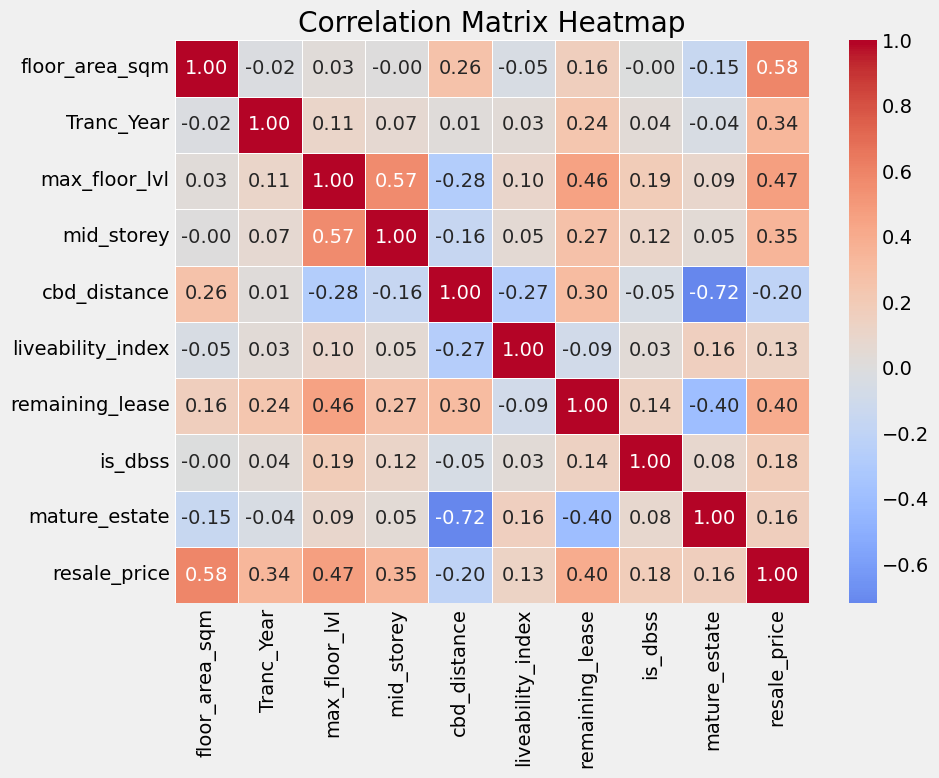

In [579]:
# Visualize correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, center=0)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

In [580]:
# Check for highly correlated features (multicollinearity)
# This helps identify features that may be redundant

CORRELATION_THRESHOLD = 0.7  # Features with correlation above this may cause issues

# Get correlation matrix without target
feature_corr = df[NUMERIC_FEATURES + ENGINEERED_FEATURES].corr()

# Find pairs of highly correlated features
high_corr_pairs = []
for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        corr_val = abs(feature_corr.iloc[i, j])
        if corr_val > CORRELATION_THRESHOLD:
            high_corr_pairs.append({
                'Feature 1': feature_corr.columns[i],
                'Feature 2': feature_corr.columns[j],
                'Correlation': feature_corr.iloc[i, j]
            })

if high_corr_pairs:
    print(f"⚠️ Highly Correlated Feature Pairs (|r| > {CORRELATION_THRESHOLD}):")
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(high_corr_df.to_string(index=False))
    print("\nConsider removing one feature from each pair to reduce multicollinearity.")
else:
    print(f"✓ No feature pairs have correlation above {CORRELATION_THRESHOLD}")

⚠️ Highly Correlated Feature Pairs (|r| > 0.7):
   Feature 1     Feature 2  Correlation
cbd_distance mature_estate    -0.718821

Consider removing one feature from each pair to reduce multicollinearity.


---

## Step 6: Prepare Data for Modeling

Handle missing values and encode categorical variables.

Two encoding strategies are used:
- **Label Encoding** -> for tree models (Random Forest, LightGBM, XGBoost, CatBoost)
- **One-Hot Encoding** -> for Linear Regression (avoids fake numeric ordering of categories)

### 6a. Drop Missing Values

In [581]:
# Create a copy of the dataframe with selected features
model_df = df[ALL_FEATURES + [TARGET_COLUMN]].copy()

# Drop rows with missing values in selected columns
initial_rows = len(model_df)
model_df = model_df.dropna()
rows_dropped = initial_rows - len(model_df)
pct_dropped = rows_dropped / initial_rows * 100
print(f"Rows before cleaning: {initial_rows}")
print(f"Rows after cleaning:  {len(model_df)}")
print(f"Rows dropped:         {rows_dropped} ({pct_dropped:.1f}%)")

Rows before cleaning: 270619
Rows after cleaning:  270619
Rows dropped:         0 (0.0%)


In [582]:
# ===== 6b. LABEL ENCODING — for tree models =====
# Tree-based models can handle integer-encoded categoricals efficiently

label_encoders = {}
model_df_encoded = model_df.copy()

if CATEGORICAL_FEATURES:
    for col in CATEGORICAL_FEATURES:
        le = LabelEncoder()
        model_df_encoded[col] = le.fit_transform(model_df_encoded[col].astype(str))
        label_encoders[col] = le
        print(f"Label encoded: {col} ({len(le.classes_)} unique values)")
else:
    print("No categorical features to label encode.")

print(f"\nmodel_df_encoded shape: {model_df_encoded.shape}")

# ===== 6c. ONE-HOT ENCODING — for Linear Regression =====
# Linear regression requires proper encoding to avoid treating categories as ordered numbers

model_df_ohe = model_df[NUMERIC_FEATURES + ENGINEERED_FEATURES + [TARGET_COLUMN]].copy()

if CATEGORICAL_FEATURES:
    ohe_dummies = pd.get_dummies(model_df[CATEGORICAL_FEATURES], drop_first=True)
    model_df_ohe = pd.concat([
        model_df_ohe.reset_index(drop=True),
        ohe_dummies.reset_index(drop=True)
    ], axis=1)
    OHE_FEATURES = NUMERIC_FEATURES + ENGINEERED_FEATURES + list(ohe_dummies.columns)
    print(f"\nOne-hot encoded: {len(ohe_dummies.columns)} dummy columns from {len(CATEGORICAL_FEATURES)} categorical features")
else:
    OHE_FEATURES = NUMERIC_FEATURES + ENGINEERED_FEATURES
    print("\nNo categorical features to one-hot encode.")

print(f"Total features for Linear Regression: {len(OHE_FEATURES)}")
print(f"model_df_ohe shape: {model_df_ohe.shape}")

Label encoded: flat_type (7 unique values)
Label encoded: flat_model (21 unique values)

model_df_encoded shape: (270619, 12)

One-hot encoded: 26 dummy columns from 2 categorical features
Total features for Linear Regression: 35
model_df_ohe shape: (270619, 36)


---

## Step 7: Split Data into Train and Test Sets

In [583]:
# ========== MODIFY THIS ==========
RANDOM_STATE = 42
TEST_SIZE = 0.25
# =================================

# --- Tree models: label-encoded features ---
X = model_df_encoded[ALL_FEATURES]
y = model_df_encoded[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# --- Linear Regression: one-hot encoded features ---
X_lr = model_df_ohe[OHE_FEATURES]
y_lr = model_df_ohe[TARGET_COLUMN]

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Training set size: {len(X_train)} ({100*(1-TEST_SIZE):.0f}%)")
print(f"Test set size:     {len(X_test)} ({100*TEST_SIZE:.0f}%)")
print(f"\nTree model features:             {len(ALL_FEATURES)}")
print(f"Linear Regression features (OHE): {len(OHE_FEATURES)}")

Training set size: 202964 (75%)
Test set size:     67655 (25%)

Tree model features:             11
Linear Regression features (OHE): 35


---

## Step 8: Define Model Evaluation Function

Create a reusable function to train models and calculate key metrics.

In [584]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Train a model and return evaluation metrics.
    
    Parameters:
    -----------
    model : estimator object
        The model to train and evaluate
    X_train, X_test : DataFrames
        Training and test features
    y_train, y_test : Series
        Training and test targets
    model_name : str
        Name for display purposes
        
    Returns:
    --------
    dict : Dictionary containing model metrics
    """
    # Fit the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    results = {
        'Model': model_name,
        'Train R²': metrics.r2_score(y_train, y_train_pred),
        'Test R²': metrics.r2_score(y_test, y_test_pred),
        'Train RMSE': np.sqrt(metrics.mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)),
        'fitted_model': model,
        'y_test_pred': y_test_pred
    }
    
    return results

def display_results(results):
    """Display formatted results for a single model."""
    print("=" * 50)
    print(f"MODEL: {results['Model']}")
    print("=" * 50)
    print(f"Train R² Score: {results['Train R²']:.4f}")
    print(f"Test R² Score:  {results['Test R²']:.4f}")
    print()
    print(f"Train RMSE: ${results['Train RMSE']:,.2f}")
    print(f"Test RMSE:  ${results['Test RMSE']:,.2f}")
    print()

---

## Step 9: Train and Evaluate Linear Regression Model (Baseline)

In [585]:
# ========== LINEAR REGRESSION (Baseline) ==========
# Uses one-hot encoded features (X_train_lr / X_test_lr)
# to avoid treating categorical labels as ordered numbers

lr_model = LinearRegression()

# Train and evaluate
lr_results = evaluate_model(lr_model, X_train_lr, X_test_lr, y_train_lr, y_test_lr, 'Linear Regression')
display_results(lr_results)

MODEL: Linear Regression
Train R² Score: 0.7895
Test R² Score:  0.7903

Train RMSE: $80,690.99
Test RMSE:  $80,444.91



In [586]:
# Display Linear Regression coefficients
# Uses OHE_FEATURES (one-hot encoded column names) to correctly label each dummy column
lr_coef_df = pd.DataFrame({
    'Feature': OHE_FEATURES,
    'Coefficient': lr_results['fitted_model'].coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Linear Regression Coefficients:")
print(f"Intercept: {lr_results['fitted_model'].intercept_:,.2f}")
print(f"\nTop 20 Feature Coefficients (by magnitude):")
print(lr_coef_df.head(20).to_string(index=False))

Linear Regression Coefficients:
Intercept: -24,103,098.59

Top 20 Feature Coefficients (by magnitude):
                          Feature   Coefficient
               flat_model_Terrace 380293.639664
                liveability_index 185985.425438
               flat_model_Type S2 183727.576645
   flat_model_Improved-Maisonette 180499.680709
flat_model_Premium Apartment Loft 137196.385944
               flat_model_Type S1 129197.300112
    flat_model_Premium Maisonette 124262.669302
    flat_model_Model A-Maisonette 110873.807971
            flat_model_Maisonette  86803.445087
         flat_model_Adjoined flat  81886.737976
       flat_type_MULTI-GENERATION  65162.884753
      flat_model_Multi Generation  65162.884753
                    mature_estate  63277.614941
                          is_dbss  49936.607364
                  flat_model_DBSS  49936.607364
                  flat_model_3Gen  45180.480942
            flat_model_Simplified  39219.922348
             flat_model_Apartment

---

## Step 10: Train and Evaluate Random Forest Model

In [587]:
# ========== RANDOM FOREST ==========
# Hyperparameters (modify as needed)
rf_model = RandomForestRegressor(
    n_estimators=100,          # Number of trees
    max_depth=15,              # Maximum depth of trees
    min_samples_split=5,       # Minimum samples to split a node
    min_samples_leaf=2,        # Minimum samples in a leaf
    random_state=RANDOM_STATE,
    n_jobs=-1                  # Use all CPU cores
)

# Train and evaluate
rf_results = evaluate_model(rf_model, X_train, X_test, y_train, y_test, 'Random Forest')
display_results(rf_results)

MODEL: Random Forest
Train R² Score: 0.9722
Test R² Score:  0.9610

Train RMSE: $29,327.92
Test RMSE:  $34,691.81



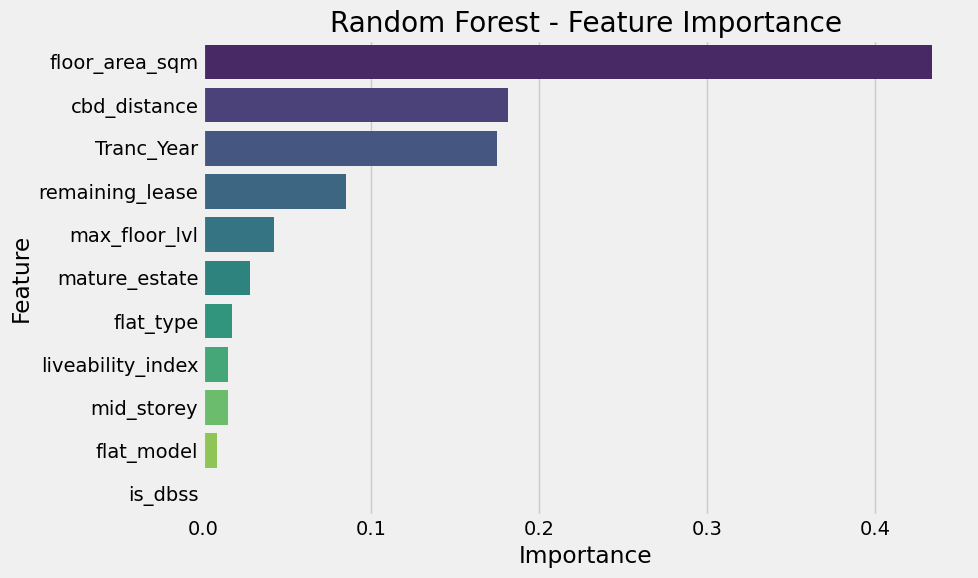

Feature Importance:
          Feature  Importance
   floor_area_sqm    0.433408
     cbd_distance    0.181598
       Tranc_Year    0.174564
  remaining_lease    0.084712
    max_floor_lvl    0.042340
    mature_estate    0.027942
        flat_type    0.017344
liveability_index    0.014751
       mid_storey    0.014653
       flat_model    0.008251
          is_dbss    0.000436


In [588]:
# Feature importance for Random Forest
rf_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': rf_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(rf_importance.to_string(index=False))

---

## Step 11: Train and Evaluate LightGBM Model

In [589]:
# ========== LIGHTGBM ==========
# Hyperparameters (modify as needed)
lgbm_model = lgb.LGBMRegressor(
    n_estimators=100,          # Number of boosting rounds
    max_depth=15,              # Maximum depth of trees
    learning_rate=0.1,         # Learning rate
    num_leaves=31,             # Maximum number of leaves in one tree
    min_child_samples=20,      # Minimum samples in a leaf
    random_state=RANDOM_STATE,
    verbose=-1                 # Suppress output
)

# Train and evaluate
lgbm_results = evaluate_model(lgbm_model, X_train, X_test, y_train, y_test, 'LightGBM')
display_results(lgbm_results)

MODEL: LightGBM
Train R² Score: 0.9532
Test R² Score:  0.9516

Train RMSE: $38,056.59
Test RMSE:  $38,635.62



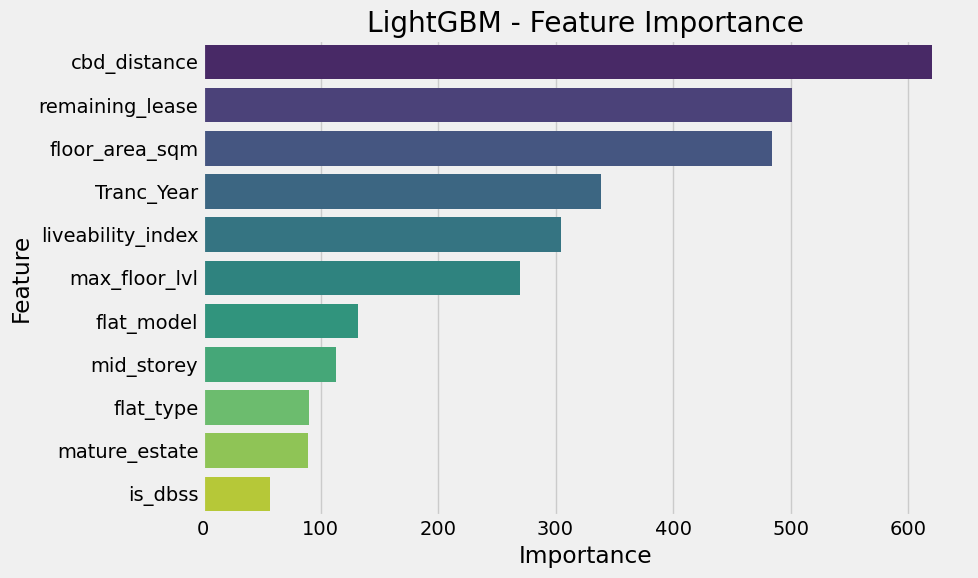

Feature Importance:
          Feature  Importance
     cbd_distance         620
  remaining_lease         501
   floor_area_sqm         484
       Tranc_Year         339
liveability_index         305
    max_floor_lvl         270
       flat_model         132
       mid_storey         113
        flat_type          90
    mature_estate          89
          is_dbss          57


In [590]:
# Feature importance for LightGBM
lgbm_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': lgbm_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=lgbm_importance, x='Importance', y='Feature', palette='viridis')
plt.title('LightGBM - Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(lgbm_importance.to_string(index=False))

---

## Step 12: Train and Evaluate XGBoost Model

In [591]:
# ========== XGBOOST ==========
# Hyperparameters (modify as needed)
xgb_model = xgb.XGBRegressor(
    n_estimators=100,          # Number of boosting rounds
    max_depth=10,              # Maximum depth of trees
    learning_rate=0.1,         # Learning rate
    min_child_weight=5,        # Minimum sum of instance weight in a child
    subsample=0.8,             # Subsample ratio of training instances
    colsample_bytree=0.8,      # Subsample ratio of columns
    random_state=RANDOM_STATE,
    verbosity=0                # Suppress output
)

# Train and evaluate
xgb_results = evaluate_model(xgb_model, X_train, X_test, y_train, y_test, 'XGBoost')
display_results(xgb_results)

MODEL: XGBoost
Train R² Score: 0.9778
Test R² Score:  0.9717

Train RMSE: $26,189.32
Test RMSE:  $29,561.93



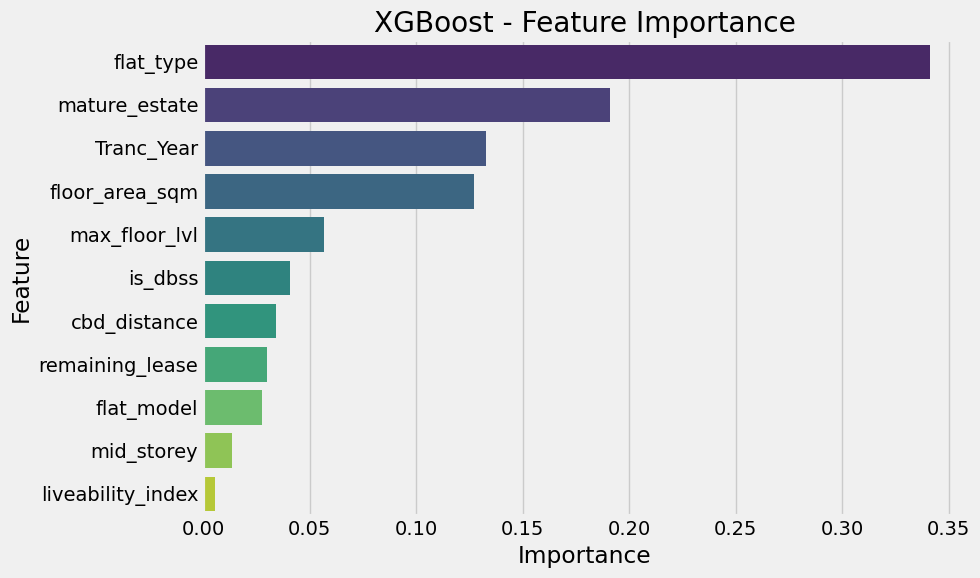

Feature Importance:
          Feature  Importance
        flat_type    0.341135
    mature_estate    0.190903
       Tranc_Year    0.132631
   floor_area_sqm    0.127009
    max_floor_lvl    0.056764
          is_dbss    0.040817
     cbd_distance    0.034179
  remaining_lease    0.029891
       flat_model    0.027672
       mid_storey    0.013468
liveability_index    0.005531


In [592]:
# Feature importance for XGBoost
xgb_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': xgb_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=xgb_importance, x='Importance', y='Feature', palette='viridis')
plt.title('XGBoost - Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(xgb_importance.to_string(index=False))

---

## Step 13: Train and Evaluate CatBoost Model

In [593]:
# ========== CATBOOST ==========
# Hyperparameters (modify as needed)
catboost_model = CatBoostRegressor(
    iterations=100,            # Number of boosting iterations
    depth=10,                  # Depth of the tree
    learning_rate=0.1,         # Learning rate
    l2_leaf_reg=3,             # L2 regularization coefficient
    random_state=RANDOM_STATE,
    verbose=0                  # Suppress output
)

# Train and evaluate
catboost_results = evaluate_model(catboost_model, X_train, X_test, y_train, y_test, 'CatBoost')
display_results(catboost_results)

MODEL: CatBoost
Train R² Score: 0.9548
Test R² Score:  0.9537

Train RMSE: $37,403.54
Test RMSE:  $37,796.87



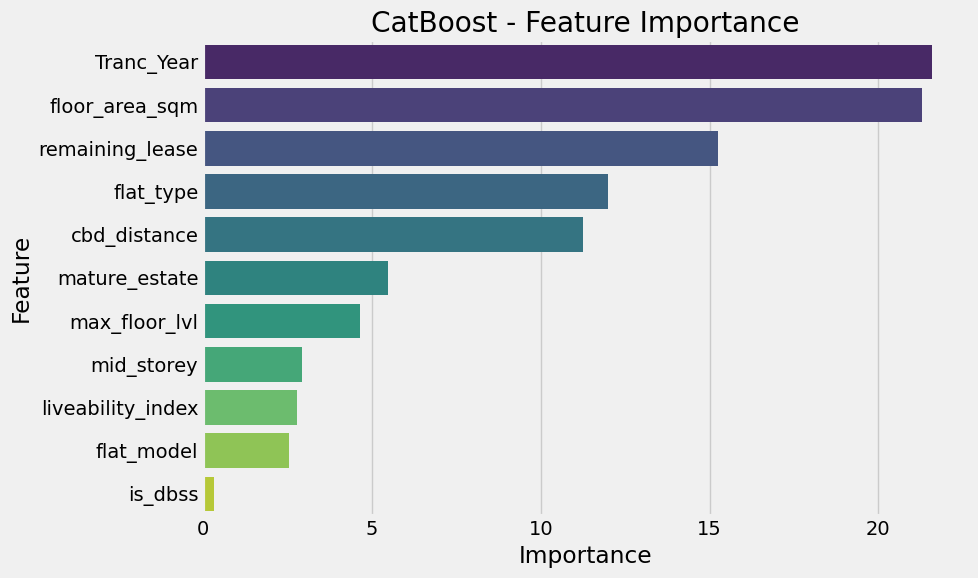

Feature Importance:
          Feature  Importance
       Tranc_Year   21.573581
   floor_area_sqm   21.279386
  remaining_lease   15.243920
        flat_type   11.989955
     cbd_distance   11.238152
    mature_estate    5.482992
    max_floor_lvl    4.632910
       mid_storey    2.924533
liveability_index    2.789810
       flat_model    2.532614
          is_dbss    0.312146


In [594]:
# Feature importance for CatBoost
catboost_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': catboost_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=catboost_importance, x='Importance', y='Feature', palette='viridis')
plt.title('CatBoost - Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(catboost_importance.to_string(index=False))

---

## Step 14: Model Comparison Summary Table

Compare the performance of all five models side-by-side.

In [595]:
# Collect results from all models (including Linear Regression baseline)
all_results = [lr_results, rf_results, lgbm_results, xgb_results, catboost_results]

# Create comparison DataFrame
comparison_df = pd.DataFrame([
    {
        'Model': r['Model'],
        'Train R²': round(r['Train R²'], 4),
        'Test R²': round(r['Test R²'], 4),
        'Train RMSE': round(r['Train RMSE'], 2),
        'Test RMSE': round(r['Test RMSE'], 2)
    }
    for r in all_results
])

# Sort by Test R² (best performance first)
comparison_df = comparison_df.sort_values('Test R²', ascending=False).reset_index(drop=True)

print("=" * 70)
print("MODEL COMPARISON SUMMARY (5 Models)")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("\n" + "=" * 70)



MODEL COMPARISON SUMMARY (5 Models)
            Model  Train R²  Test R²  Train RMSE  Test RMSE
          XGBoost    0.9778   0.9717    26189.32   29561.93
    Random Forest    0.9722   0.9610    29327.92   34691.81
         CatBoost    0.9548   0.9537    37403.54   37796.87
         LightGBM    0.9532   0.9516    38056.59   38635.62
Linear Regression    0.7895   0.7903    80690.99   80444.91



In [596]:
# Save a CSV with a fixed model order (independent of cell 42 display sorting)
export_order = ['Linear Regression', 'Random Forest', 'LightGBM', 'XGBoost', 'CatBoost']

comparison_df_export = comparison_df.copy()
comparison_df_export['Model'] = pd.Categorical(
    comparison_df_export['Model'],
    categories=export_order,
    ordered=True
)
comparison_df_export = comparison_df_export.sort_values('Model').reset_index(drop=True)

comparison_df_export.to_csv('model_comparison_results.csv', index=False)
print("Saved model_comparison_results.csv with model order:")
print("Linear Regression -> Random Forest -> LightGBM -> XGBoost -> CatBoost")

Saved model_comparison_results.csv with model order:
Linear Regression -> Random Forest -> LightGBM -> XGBoost -> CatBoost


In [597]:
# Identify best model
best_model_idx = comparison_df['Test R²'].idxmax()
best_model = comparison_df.loc[best_model_idx]

print("\n" + "*" * 50)
print("BEST PERFORMING MODEL")
print("*" * 50)
print(f"Model: {best_model['Model']}")
print(f"Test R²: {best_model['Test R²']:.4f}")
print(f"Test RMSE: ${best_model['Test RMSE']:,.2f}")
print("*" * 50)


**************************************************
BEST PERFORMING MODEL
**************************************************
Model: XGBoost
Test R²: 0.9717
Test RMSE: $29,561.93
**************************************************


---

## Summary Checklist

- [ ] **Step 1:** Identified target variable (`resale_price`)
- [ ] **Step 2:** Imported packages and loaded data
- [ ] **Step 3:** Explored dataset structure
- [ ] **Step 3.5:** Feature engineering (optional)
- [ ] **Step 4:** Selected features for modeling
- [ ] **Step 5:** Analyzed feature correlations
- [ ] **Step 6:** Prepared data (handled missing values, encoded categoricals)
- [ ] **Step 7:** Split data into train/test sets
- [ ] **Step 8:** Defined model evaluation function
- [ ] **Step 9:** Trained Linear Regression model (Baseline)
- [ ] **Step 10:** Trained Random Forest model
- [ ] **Step 11:** Trained LightGBM model
- [ ] **Step 12:** Trained XGBoost model
- [ ] **Step 13:** Trained CatBoost model
- [ ] **Step 14:** Compared all 5 models (R² and RMSE)